# Tool-Specific Reanalysis of Tully, Longoni, and Appel (2025) — Study 3

This notebook reproduces every numerical result and figure used in the paper
**"AI Receptivity or AI Adoption Breadth? A Tool-Specific Reanalysis of the Lower-Literacy / Higher-Usage Link"**.

It re-fits four model families on the publicly released Study 3 data of Tully, Longoni, and Appel (2025), under three
outcome groupings: pooled five-tool, text-AI only, and non-text AI only. Item-level models include task fixed effects.
All computations rely on the project's `tully_ai_literacy_robustness.py` library.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Make the project library importable.
PROJECT_DIR = Path('.').resolve()
sys.path.insert(0, str(PROJECT_DIR))
from tully_ai_literacy_robustness import (
    build_long, fit_binary_logit, fit_multinomial_logit, fit_ols_average,
    fit_ordered_logit, make_exog, predicted_probabilities_ordered, read_table,
)

DATA_PATH = PROJECT_DIR / 'S3_data.xlsx'
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

LITERACY = 'SC0'
COVARS = ['Age', 'Income', 'GenKnow', 'Autonomy', 'Gender']
NONTEXT = ['AI_image', 'AI_productivity', 'AI_website', 'AI_healthapp']
ALL5 = NONTEXT + ['AI_text']

raw = read_table(DATA_PATH)
print('Shape:', raw.shape)
raw[['SC0', *ALL5, *COVARS]].describe().round(2)

Excel sheets in S3_data.xlsx: ['S3_data_full']
Using sheet: S3_data_full
Shape: (408, 76)


,SC0,AI_image,AI_productivity,AI_website,AI_healthapp,AI_text,Age,Income,GenKnow,Autonomy,Gender
count,404.00,401.00,401.00,401.00,401.00,401.00,404.00,404.00,401.00,401.00,401.00
mean,12.48,1.66,1.41,1.47,1.71,2.59,44.18,2.85,14.63,6.19,1.49
std,2.30,1.04,0.91,0.97,1.16,1.42,14.67,1.08,3.44,0.84,0.62
min,1.00,1.00,1.00,1.00,1.00,1.00,21.00,1.00,1.00,2.00,1.00
25%,11.00,1.00,1.00,1.00,1.00,1.00,34.00,2.00,13.00,5.75,1.00
50%,13.00,1.00,1.00,1.00,1.00,2.00,42.00,3.00,15.00,6.25,1.00
75%,14.00,2.00,1.00,1.00,2.00,4.00,53.25,4.00,17.00,7.00,2.00
max,17.00,5.00,5.00,5.00,5.00,5.00,174.31,5.00,20.00,7.00,5.00


## 1. Descriptive picture

Each AI tool is rated on a 1–5 frequency scale. The empirical distribution shows that non-text
categories are very right-skewed: most respondents have never used image generators, productivity tools,
website builders, or health apps. Text AI (ChatGPT-style) is the only category where a clear majority
of respondents are users.

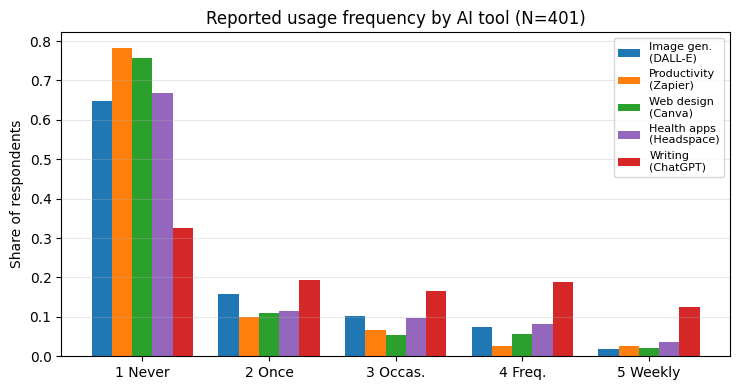

In [2]:
labels = {
    'AI_image': 'Image gen.\n(DALL-E)',
    'AI_productivity': 'Productivity\n(Zapier)',
    'AI_website': 'Web design\n(Canva)',
    'AI_healthapp': 'Health apps\n(Headspace)',
    'AI_text': 'Writing\n(ChatGPT)',
}
fig, ax = plt.subplots(figsize=(7.5, 4.0))
width = 0.16
x_cats = np.arange(1, 6)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']
for i, col in enumerate(ALL5):
    counts = raw[col].dropna().astype(int).value_counts().reindex(x_cats, fill_value=0)
    ax.bar(x_cats + (i - 2) * width, counts / counts.sum(), width=width,
           color=colors[i], label=labels[col])
ax.set_xticks(x_cats)
ax.set_xticklabels(['1 Never', '2 Once', '3 Occas.', '4 Freq.', '5 Weekly'])
ax.set_ylabel('Share of respondents')
ax.set_title('Reported usage frequency by AI tool (N=401)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'usage_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 2. Block A — Pooled five-tool replication

We re-fit the original Study 3 specification using all five tool categories, with the same
covariates the paper reports: age, income, general knowledge, motivation for autonomy, and gender.
We obtain four estimates: OLS on participant-level averages, binary logit at the scale midpoint,
ordered logit (proportional odds), and a fully nominal multinomial logit. Item-level models include
task fixed effects.

In [3]:
long_pooled = build_long(raw, LITERACY, ALL5, id_col=None, covariates=COVARS)
id_col = '__row_id__'
fit_ols_average(long_pooled, id_col=id_col, literacy_col=LITERACY, covariates=COVARS)
fit_binary_logit(long_pooled, covariates=COVARS)
fit_ordered_logit(long_pooled, covariates=COVARS)
fit_multinomial_logit(long_pooled, covariates=COVARS)
predicted_probabilities_ordered(long_pooled, covariates=COVARS)


1) OLS on participant-level average response
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.7666      0.036     48.953      0.000       1.696       1.837
z_literacy    -0.1785      0.053     -3.377      0.001      -0.282      -0.075
z_Age         -0.2051      0.032     -6.342      0.000      -0.268      -0.142
z_Income       0.0475      0.038      1.257      0.209      -0.027       0.122
z_GenKnow     -0.0852      0.047     -1.819      0.069      -0.177       0.007
z_Autonomy    -0.0472      0.049     -0.960      0.337      -0.143       0.049
z_Gender      -0.1001      0.038     -2.613      0.009      -0.175      -0.025

2) Binary logit on item-level response, thresholded at scale midpoint
Threshold: y > 3
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -2046.9
Model:                   OrderedModel   AIC:                             4122.
Method:            Maximum Likelihood   BIC:                             4200.
Date:                Tue, 26 May 2026                                         
Time:                        18:05:40                                         
No. Observations:                2005                                         
Df Residuals:                    1991                                         
Df Model:                          10                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
z_literacy              -0.3055      0.054     -5.646      0.000      -0.412      -0.199
z_Age                 

 z_literacy  P(y=1)  P(y=2)  P(y=3)  P(y=4)  P(y=5)
         -2   0.526   0.187   0.134   0.105   0.047
         -1   0.601   0.171   0.111   0.082   0.035
          0   0.671   0.149   0.090   0.063   0.026
          1   0.735   0.126   0.071   0.048   0.020
          2   0.790   0.104   0.056   0.036   0.014


## 3. Block B — Text AI only

If the pooled effect is really about general AI receptivity, it should also appear when text AI
is examined on its own. We re-fit the four model families on the single `AI_text` outcome.

In [4]:
long_text = build_long(raw, LITERACY, ['AI_text'], id_col=None, covariates=COVARS)
fit_ols_average(long_text, id_col=id_col, literacy_col=LITERACY, covariates=COVARS)
fit_binary_logit(long_text, covariates=COVARS)
fit_ordered_logit(long_text, covariates=COVARS)
fit_multinomial_logit(long_text, covariates=COVARS)
predicted_probabilities_ordered(long_text, covariates=COVARS)


1) OLS on participant-level average response
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.5910      0.068     37.928      0.000       2.457       2.725
z_literacy    -0.0753      0.081     -0.929      0.353      -0.234       0.084
z_Age         -0.2830      0.068     -4.157      0.000      -0.416      -0.150
z_Income       0.1426      0.066      2.158      0.031       0.013       0.272
z_GenKnow     -0.0280      0.082     -0.339      0.734      -0.190       0.134
z_Autonomy    -0.0338      0.075     -0.453      0.650      -0.180       0.112
z_Gender      -0.3216      0.068     -4.728      0.000      -0.455      -0.188

2) Binary logit on item-level response, thresholded at scale midpoint
Threshold: y > 3
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

 z_literacy  P(y=1)  P(y=2)  P(y=3)  P(y=4)  P(y=5)
         -2   0.274   0.203   0.184   0.209   0.130
         -1   0.293   0.208   0.181   0.198   0.120
          0   0.314   0.212   0.178   0.187   0.110
          1   0.335   0.214   0.173   0.177   0.101
          2   0.357   0.216   0.169   0.166   0.092


## 4. Block C — Non-text AI only (image, productivity, website, health app)

In [5]:
long_nontext = build_long(raw, LITERACY, NONTEXT, id_col=None, covariates=COVARS)
fit_ols_average(long_nontext, id_col=id_col, literacy_col=LITERACY, covariates=COVARS)
fit_binary_logit(long_nontext, covariates=COVARS)
fit_ordered_logit(long_nontext, covariates=COVARS)
fit_multinomial_logit(long_nontext, covariates=COVARS)
predicted_probabilities_ordered(long_nontext, covariates=COVARS)


1) OLS on participant-level average response
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5605      0.035     45.063      0.000       1.493       1.628
z_literacy    -0.2043      0.053     -3.819      0.000      -0.309      -0.099
z_Age         -0.1856      0.030     -6.172      0.000      -0.245      -0.127
z_Income       0.0237      0.037      0.648      0.517      -0.048       0.095
z_GenKnow     -0.0995      0.046     -2.163      0.031      -0.190      -0.009
z_Autonomy    -0.0505      0.050     -1.017      0.309      -0.148       0.047
z_Gender      -0.0447      0.037     -1.220      0.223      -0.116       0.027

2) Binary logit on item-level response, thresholded at scale midpoint
Threshold: y > 3
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -1425.9
Model:                   OrderedModel   AIC:                             2878.
Method:            Maximum Likelihood   BIC:                             2948.
Date:                Tue, 26 May 2026                                         
Time:                        18:05:42                                         
No. Observations:                1604                                         
Df Residuals:                    1591                                         
Df Model:                           9                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
z_literacy              -0.3758      0.063     -5.983      0.000      -0.499      -0.253
z_Age                 

 z_literacy  P(y=1)  P(y=2)  P(y=3)  P(y=4)  P(y=5)
         -2   0.496   0.190   0.150   0.117   0.048
         -1   0.589   0.171   0.121   0.086   0.033
          0   0.676   0.146   0.093   0.062   0.023
          1   0.753   0.118   0.069   0.044   0.016
          2   0.816   0.092   0.051   0.031   0.011


## 5. Block D — Non-text AI, adoption threshold (y > 1)

Recoding the dependent variable as `1 = at least once / 0 = never` isolates the adoption margin
from the intensive-use margin.

In [6]:
fit_binary_logit(long_nontext, covariates=COVARS, threshold=1)


2) Binary logit on item-level response, thresholded at scale midpoint
Threshold: y > 1
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.7918      0.118     -6.731      0.000      -1.022      -0.561
z_literacy              -0.3848      0.068     -5.623      0.000      -0.519      -0.251
z_Age                   -0.5806      0.066     -8.835      0.000      -0.709      -0.452
z_Income                 0.0990      0.059      1.676      0.094      -0.017       0.215
z_GenKnow               -0.1707      0.069     -2.463      0.014      -0.307      -0.035
z_Autonomy              -0.1250      0.059     -2.134      0.033      -0.240      -0.010
z_Gender                -0.1023      0.059     -1.740      0.082      -0.218       0.013
task_AI_image            0.1005      0.163      0.615      0.538      -0.220       0.421
task_AI_productivity  

## 6. Predicted probability of non-use (Figure 1 of the paper)

From the ordered-logit fits we predict $\Pr(Y = 1)$ over a grid of standardized literacy values
for the text-only and non-text-only models. The slope is much steeper for non-text tools.

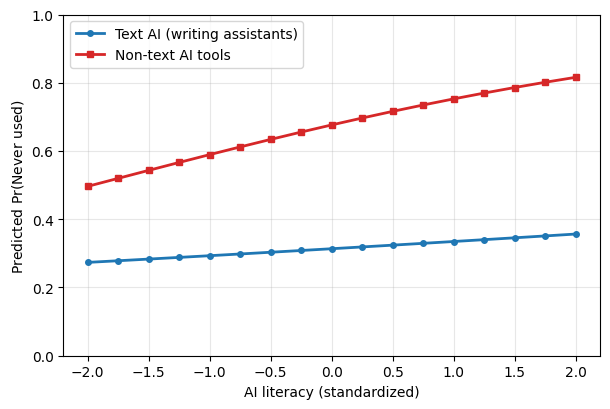

In [7]:
grid = np.linspace(-2.0, 2.0, 17)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for label, cols, color, marker in [
    ('Text AI (writing assistants)', ['AI_text'], '#1f77b4', 'o'),
    ('Non-text AI tools', NONTEXT, '#d62728', 's'),
]:
    long = build_long(raw, LITERACY, cols, id_col=None, covariates=COVARS)
    exog = make_exog(long, covariates=COVARS, task_fe=True)
    res = OrderedModel(long['y'].astype(int), exog, distr='logit').fit(
        method='bfgs', maxiter=1000, disp=False)
    base = pd.DataFrame(np.zeros((len(grid), exog.shape[1])), columns=exog.columns)
    base['z_literacy'] = grid
    pred = res.model.predict(res.params, exog=base)
    ax.plot(grid, pred[:, 0], marker=marker, color=color, linewidth=2,
            markersize=4, label=label)
ax.set_xlabel('AI literacy (standardized)')
ax.set_ylabel(r'Predicted $\Pr(\text{Never used})$')
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(FIG_DIR / 'predicted_prob_never.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 7. Coefficient summary (Figure 2 of the paper)

Side-by-side comparison of the AI-literacy coefficient by tool group and by model family.

In [8]:
rows = []
for group_label, cols in [('Pooled (5 tools)', ALL5),
                          ('Non-text only', NONTEXT),
                          ('Text only', ['AI_text'])]:
    long = build_long(raw, LITERACY, cols, id_col=None, covariates=COVARS)
    exog = make_exog(long, covariates=COVARS, task_fe=True)
    res = OrderedModel(long['y'].astype(int), exog, distr='logit').fit(
        method='bfgs', maxiter=1000, disp=False)
    rows.append({'group': group_label, 'model': 'Ordered logit',
                 'beta': float(res.params['z_literacy']),
                 'se': float(res.bse['z_literacy'])})
    for thr, model_label in [(3, 'Binary logit (y>3)'), (1, 'Binary adoption (y>1)')]:
        dat = long.copy(); dat['y_bin'] = (dat['y'] > thr).astype(int)
        ex = sm.add_constant(make_exog(dat, covariates=COVARS, task_fe=True),
                             has_constant='add')
        m = sm.GLM(dat['y_bin'], ex, family=sm.families.Binomial()).fit(cov_type='HC3')
        rows.append({'group': group_label, 'model': model_label,
                     'beta': float(m.params['z_literacy']),
                     'se': float(m.bse['z_literacy'])})
coef_df = pd.DataFrame(rows)
coef_df.round(3)

,group,model,beta,se
0,Pooled (5 tools),Ordered logit,-0.306,0.054
1,Pooled (5 tools),Binary logit (y>3),-0.328,0.086
2,Pooled (5 tools),Binary adoption (y>1),-0.327,0.061
3,Non-text only,Ordered logit,-0.376,0.063
4,Non-text only,Binary logit (y>3),-0.404,0.104
5,Non-text only,Binary adoption (y>1),-0.385,0.068
6,Text only,Ordered logit,-0.097,0.105
7,Text only,Binary logit (y>3),-0.112,0.142
8,Text only,Binary adoption (y>1),-0.060,0.131


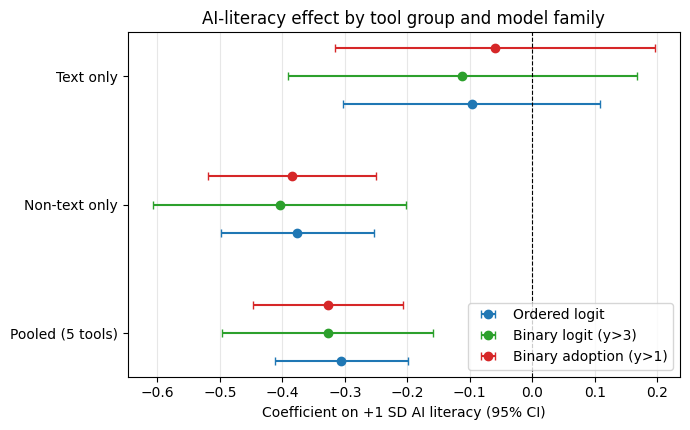

In [9]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
groups = ['Pooled (5 tools)', 'Non-text only', 'Text only']
models = ['Ordered logit', 'Binary logit (y>3)', 'Binary adoption (y>1)']
colors = {'Ordered logit': '#1f77b4', 'Binary logit (y>3)': '#2ca02c',
          'Binary adoption (y>1)': '#d62728'}
y_positions = np.arange(len(groups))
offsets = {m: (i - 1) * 0.22 for i, m in enumerate(models)}
for model in models:
    sub = coef_df[coef_df['model'] == model]
    for _, row in sub.iterrows():
        ypos = y_positions[groups.index(row['group'])] + offsets[model]
        ci_lo, ci_hi = row['beta'] - 1.96 * row['se'], row['beta'] + 1.96 * row['se']
        ax.errorbar(row['beta'], ypos,
                    xerr=[[row['beta'] - ci_lo], [ci_hi - row['beta']]],
                    fmt='o', color=colors[model], capsize=3,
                    label=model if row['group'] == 'Pooled (5 tools)' else None)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_positions); ax.set_yticklabels(groups)
ax.set_xlabel('Coefficient on +1 SD AI literacy (95% CI)')
ax.set_title('AI-literacy effect by tool group and model family')
ax.legend(loc='lower right'); ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'coefficient_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 8. Summary

The pooled negative association replicates under every model family. Once the outcome is decomposed,
the AI-literacy slope is small and non-significant for text AI (ordered-logit $\beta=-0.097$, $p=.357$)
but strong for non-text AI ($\beta=-0.376$, $p<.001$). For non-text tools, the per-SD odds ratio of
ever having used the tool is $\approx 0.68$. Study 3 thus carries the most weight for **non-text AI adoption
breadth** rather than for general AI receptivity or text-AI usage intensity.